In [3]:
'''
EJERCICIO_2:
Desarrolle una clase en Python que implemente desde cero:
- Constructor con normalización automática.
- Métodos from_axis_angle y from_euler_zyz.
- Sobrecarga del operador __mul__ para el producto de Hamilton.
- Métodos rotate_vector (sándwich), to_rotation_matrix y to_ros_msg (orden x,y,z,w).
'''
import numpy as np

class Quaternion:
    def __init__(self, w: float = 1.0, x: float = 0.0, y: float = 0.0, z: float = 0.0):
        """
        Constructor que inicializa el cuaternión en convención estándar [w, x, y, z]
        y aplica normalización automática para asegurar pertenencia a S^3.
        """
        norm = np.sqrt(w**2 + x**2 + y**2 + z**2)
        if np.isclose(norm, 0.0):
            raise ValueError("No se puede crear un cuaternión de norma cero.")
        # Normalización automática
        self.w = float(w / norm)
        self.x = float(x / norm)
        self.y = float(y / norm)
        self.z = float(z / norm)

    @property
    def v(self) -> np.ndarray:
        # Parte vectorial del cuaternión.
        return np.array([self.x, self.y, self.z], dtype=np.float64)

    @property
    def conjugate(self) -> 'Quaternion':
        # Calcula el conjugado q* = [w, -v]
        return Quaternion(self.w, -self.x, -self.y, -self.z)
   
    # Constructores Alternativos / Métodos de Fábrica
   
    @classmethod
    def from_axis_angle(cls, axis: np.ndarray, theta_deg: float) -> 'Quaternion':
        
       #Crea un cuaternión a partir de un eje unitario u y un ángulo theta en grados.
        axis = np.array(axis, dtype=np.float64)
        axis_norm = np.linalg.norm(axis)
        if np.isclose(axis_norm, 0.0):
            raise ValueError("El eje de rotación no puede ser un vector nulo.")
        
        u = axis / axis_norm
        rad = np.radians(theta_deg)
        w = np.cos(rad / 2.0)
        xyz = u * np.sin(rad / 2.0)
        return cls(w, xyz[0], xyz[1], xyz[2])

    @classmethod
    def from_euler_zyz(cls, phi_deg: float, theta_deg: float, psi_deg: float) -> 'Quaternion':
        # Crea un cuaternión a partir de la secuencia de Euler ZYZ:
        q_phi = cls.from_axis_angle([0, 0, 1], phi_deg)
        q_theta = cls.from_axis_angle([0, 1, 0], theta_deg)
        q_psi = cls.from_axis_angle([0, 0, 1], psi_deg)
        
        # Producto encadenado por la derecha (ejes móviles)
        return q_phi * q_theta * q_psi
        
    # Sobrecarga de Operadores (Producto de Hamilton)
    def __mul__(self, other: 'Quaternion') -> 'Quaternion':
        
        # Sobrecarga del operador '*' para realizar el Producto de Hamilton:
        
        if not isinstance(other, Quaternion):
            raise TypeError("La multiplicación solo está soportada entre objetos Quaternion.")
        
        w1, v1 = self.w, self.v
        w2, v2 = other.w, other.v
        
        w_res = w1 * w2 - np.dot(v1, v2)
        v_res = w1 * v2 + w2 * v1 + np.cross(v1, v2)
        
        return Quaternion(w_res, v_res[0], v_res[1], v_res[2])
    # Métodos de Transformación y Conversión
    def rotate_vector(self, p: np.ndarray) -> np.ndarray:
        # Aplica el Operador Sándwich: p' = q (x) [0, p] (x) q*
        # Equivalente a la Fórmula de Rodrigues.
        p = np.array(p, dtype=np.float64)
        p_quat = Quaternion(0.0, p[0], p[1], p[2])
        p_rot = (self * p_quat) * self.conjugate
        return p_rot.v

    def to_rotation_matrix(self) -> np.ndarray:
        # Convierte el cuaternión a su matriz equivalente R en SO(3)
        qw, qx, qy, qz = self.w, self.x, self.y, self.z
        return np.array([
            [1.0 - 2.0*(qy**2 + qz**2),       2.0*(qx*qy - qw*qz),       2.0*(qx*qz + qw*qy)],
            [      2.0*(qx*qy + qw*qz), 1.0 - 2.0*(qx**2 + qz**2),       2.0*(qy*qz - qw*qx)],
            [      2.0*(qx*qz - qw*qy),       2.0*(qy*qz + qw*qx), 1.0 - 2.0*(qx**2 + qy**2)]
        ], dtype=np.float64)

    def to_ros_msg(self) -> dict:
        # Exporta el cuaternión en la convención de ROS / ROS 2 (geometry_msgs/Quaternion):
        # Orden: [x, y, z, w] con el escalar 'w' al final.
        
        return {
            'x': self.x,
            'y': self.y,
            'z': self.z,
            'w': self.w
        }

    def __repr__(self) -> str:
        return f"Quaternion(w={self.w:.4f}, x={self.x:.4f}, y={self.y:.4f}, z={self.z:.4f})"

# Prueba y Validación
if __name__ == "__main__":
    print("--- 1. Creación por Eje-Ángulo (90° en Z) ---")
    q1 = Quaternion.from_axis_angle([0, 0, 1], 90.0)
    print("q1:", q1)

    print("\n--- 2. Rotación de Vector (Sándwich) ---")
    p = np.array([1.0, 0.0, 0.0])
    p_rot = q1.rotate_vector(p)
    print(f"Vector original: {p}")
    print(f"Vector rotado 90° en Z: {np.round(p_rot, 4)}")

    print("\n--- 3. Matriz de Rotación SO(3) ---")
    R = q1.to_rotation_matrix()
    print(np.round(R, 4))

    print("\n--- 4. Formato de Mensaje ROS (geometry_msgs/Quaternion) ---")
    print(q1.to_ros_msg())

    print("\n--- 5. Cuaternión desde Euler ZYZ (45°, 30°, 60°) ---")
    q_zyz = Quaternion.from_euler_zyz(45.0, 30.0, 60.0)
    print("q_zyz:", q_zyz)

--- 1. Creación por Eje-Ángulo (90° en Z) ---
q1: Quaternion(w=0.7071, x=0.0000, y=0.0000, z=0.7071)

--- 2. Rotación de Vector (Sándwich) ---
Vector original: [1. 0. 0.]
Vector rotado 90° en Z: [0. 1. 0.]

--- 3. Matriz de Rotación SO(3) ---
[[-0. -1.  0.]
 [ 1. -0.  0.]
 [ 0.  0.  1.]]

--- 4. Formato de Mensaje ROS (geometry_msgs/Quaternion) ---
{'x': 0.0, 'y': 0.0, 'z': 0.7071067811865476, 'w': 0.7071067811865476}

--- 5. Cuaternión desde Euler ZYZ (45°, 30°, 60°) ---
q_zyz: Quaternion(w=0.5880, x=0.0338, y=0.2566, z=0.7663)


Cuaternión Inicial q0: [0.9659 0.     0.2588 0.    ]
Cuaternión Final   q1: [ 0.3314 -0.1913  0.4619  0.8001]
Total de poses intermedias calculadas: 100


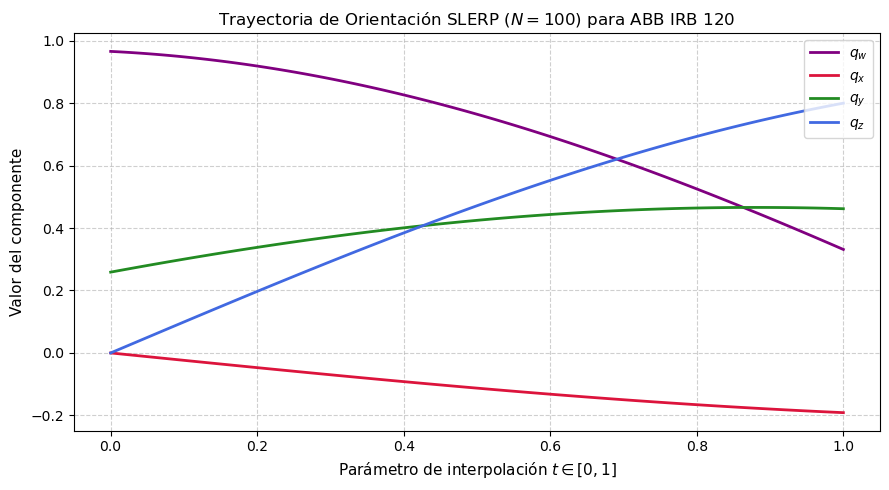

In [4]:
'''
EJERCICIO_3: SLERP y Camino Más Corto
Implemente la función slerp(q0, q1, t) con corrección antipodal (q0 · q1 < 0) y límite
LERP. Para el ABB IRB 120, interpole N = 100 pasos entre:
◦ Pose inicial (ZYZ): ϕ0 = 0◦,θ0 = 30◦,ψ0 = 0◦
◦ Pose final (ZYZ): ϕ1 = 90◦,θ1 = 60◦,ψ1 = 45°
'''
import numpy as np
import matplotlib.pyplot as plt

def euler_zyz_to_quat(phi_deg, theta_deg, psi_deg):
    # Conversión de ángulos de Euler ZYZ a cuaternión unitario [w, x, y, z].
    phi, theta, psi = np.radians([phi_deg, theta_deg, psi_deg])
    
    # Cuaterniones elementales
    qz1 = np.array([np.cos(phi / 2), 0, 0, np.sin(phi / 2)])
    qy  = np.array([np.cos(theta / 2), 0, np.sin(theta / 2), 0])
    qz2 = np.array([np.cos(psi / 2), 0, 0, np.sin(psi / 2)])
    
    def quat_mult(q1, q2):
        w1, x1, y1, z1 = q1
        w2, x2, y2, z2 = q2
        return np.array([
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        ])
    
    q_res = quat_mult(quat_mult(qz1, qy), qz2)
    return q_res / np.linalg.norm(q_res)

def slerp(q0: np.ndarray, q1: np.ndarray, t: float, eps: float = 1e-6) -> np.ndarray:
    
    # Interpolación Esférica Lineal (SLERP) con:
    # 1. Corrección antipodal para garantizar el camino más corto.
    # 2. Fallback a LERP normalizado para ángulos muy pequeños (Omega -> 0).

    q0 = q0 / np.linalg.norm(q0)
    q1 = q1 / np.linalg.norm(q1)
    
    dot = np.dot(q0, q1)
    
    # 1. Corrección Antipodal (Shortest Path)
    if dot < 0.0:
        q1 = -q1
        dot = -dot
        
    dot = np.clip(dot, -1.0, 1.0)
    Omega = np.arccos(dot)
    
    # 2. Límite LERP si el ángulo es casi cero
    if np.sin(Omega) < eps:
        q_t = (1.0 - t) * q0 + t * q1
    else:
        sin_Omega = np.sin(Omega)
        q_t = (np.sin((1.0 - t) * Omega) / sin_Omega) * q0 + (np.sin(t * Omega) / sin_Omega) * q1
        
    return q_t / np.linalg.norm(q_t)

# Poses del ABB IRB 120

# Pose inicial: phi=0°, theta=30°, psi=0°
q0 = euler_zyz_to_quat(0.0, 30.0, 0.0)

# Pose final: phi=90°, theta=60°, psi=45°
q1 = euler_zyz_to_quat(90.0, 60.0, 45.0)

# Generación de N = 100 pasos
N = 100
t_values = np.linspace(0.0, 1.0, N)
trayectoria_quats = np.array([slerp(q0, q1, t) for t in t_values])

print("=" * 60)
print(f"Cuaternión Inicial q0: {np.round(q0, 4)}")
print(f"Cuaternión Final   q1: {np.round(q1, 4)}")
print(f"Total de poses intermedias calculadas: {len(trayectoria_quats)}")
print("=" * 60)

# Gráfica de los Componentes del Cuaternión a lo largo del tiempo

plt.figure(figsize=(9, 5))
labels = [r'$q_w$', r'$q_x$', r'$q_y$', r'$q_z$']
colors = ['purple', 'crimson', 'forestgreen', 'royalblue']

for i in range(4):
    plt.plot(t_values, trayectoria_quats[:, i], label=labels[i], color=colors[i], linewidth=2.0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Parámetro de interpolación $t \in [0, 1]$', fontsize=11)
plt.ylabel('Valor del componente', fontsize=11)
plt.title('Trayectoria de Orientación SLERP ($N=100$) para ABB IRB 120', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
'''
EJERCICIO_4: 

'''
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# Funciones: Cuaternión a Matriz y SLERP
# ==============================================================================
def quat_to_rot(q):
    """Convierte un cuaternión unitario q = [qw, qx, qy, qz] a matriz SO(3)"""
    qw, qx, qy, qz = q
    return np.array([
        [1 - 2*(qy**2 + qz**2),     2*(qx*qy - qw*qz),     2*(qx*qz + qw*qy)],
        [    2*(qx*qy + qw*qz), 1 - 2*(qx**2 + qz**2),     2*(qy*qz - qw*qx)],
        [    2*(qx*qz - qw*qy),     2*(qy*qz + qw*qx), 1 - 2*(qx**2 + qy**2)]
    ])

def slerp(q0, q1, t):
    """Interpolación esférica lineal entre q0 y q1"""
    dot = np.dot(q0, q1)
    
    # Asegurar el camino más corto (Shortest Path)
    if dot < 0.0:
        q1 = -q1
        dot = -dot
        
    dot = np.clip(dot, -1.0, 1.0)
    Omega = np.arccos(dot)
    
    if np.isclose(Omega, 0.0):
        return q0
    
    sin_Omega = np.sin(Omega)
    q_t = (np.sin((1.0 - t) * Omega) / sin_Omega) * q0 + (np.sin(t * Omega) / sin_Omega) * q1
    return q_t / np.linalg.norm(q_t)

# ==============================================================================
# Definición de dos cuaterniones arbitrarios (ej. giro en X vs giro en Z)
# ==============================================================================
# q0: Rotación de 0° (Identidad)
q0 = np.array([1.0, 0.0, 0.0, 0.0])

# q1: Rotación de 90° alrededor del eje [1, 1, 1]/sqrt(3)
theta = np.radians(90)
u = np.array([1.0, 1.0, 1.0]) / np.sqrt(3)
q1 = np.array([np.cos(theta/2), *(u * np.sin(theta/2))])

# Vector de tiempo discreto
N = 500
t_total = 2.0  # Duración de 2 segundos
time_vec = np.linspace(0.0, t_total, N)
dt = time_vec[1] - time_vec[0]

# ==============================================================================
# Cálculo de matrices R(t) y extracción de velocidad angular
# ==============================================================================
R_list = []
for t_val in (time_vec / t_total):
    q_interp = slerp(q0, q1, t_val)
    R_list.append(quat_to_rot(q_interp))

omega_norms = []
t_mid = []

for k in range(N - 1):
    R_k = R_list[k]
    R_kp1 = R_list[k + 1]
    
    # Aproximación de derivada y matriz antisimétrica
    R_dot = (R_kp1 - R_k) / dt
    omega_skew = R_dot @ R_k.T
    
    # Extracción del vector omega
    wx = omega_skew[2, 1]
    wy = omega_skew[0, 2]
    wz = omega_skew[1, 0]
    
    omega_vec = np.array([wx, wy, wz])
    omega_norms.append(np.linalg.norm(omega_vec))
    t_mid.append(time_vec[k])

omega_norms = np.array(omega_norms)

# ==============================================================================
# Validación Numérica de Velocidad Constante (Error < 0.5%)
# ==============================================================================
omega_mean = np.mean(omega_norms)
error_relativo = np.max(np.abs(omega_norms - omega_mean) / omega_mean) * 100

print("=" * 55)
print("VALIDACIÓN CINEMÁTICA SLERP")
print("=" * 55)
print(f"Velocidad angular media ||w||: {omega_mean:.6f} rad/s")
print(f"Error relativo máximo:        {error_relativo:.4f} %")
print(f"¿Cumple con Error < 0.5%?:    {error_relativo < 0.5}")
print("=" * 55)

# ==============================================================================
# Gráfica
# ==============================================================================
plt.figure(figsize=(9, 4.5))
plt.plot(t_mid, omega_norms, color='royalblue', linewidth=2.5, label=r'$\|\boldsymbol{\omega}(t_k)\|$ medido')
plt.axhline(y=omega_mean, color='darkorange', linestyle='--', linewidth=1.8, label=f'Promedio ({omega_mean:.4f} rad/s)')
plt.ylim(omega_mean * 0.95, omega_mean * 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Tiempo $t$ [s]', fontsize=11)
plt.ylabel(r'$\|\boldsymbol{\omega}\|$ [rad/s]', fontsize=11)
plt.title(r'Validación Cinemática: Magnitud de Velocidad Angular en SLERP', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()